# EDA - Proyecto Final Mineria de Datos (GRUPO 8)

### Proyecto Exploratorio de Datos 11 Pasos 
### Dataset Air QualityUCI.csv

# Paos 1. Importar Librerias

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from tabulate import tabulate
from sklearn.preprocessing import LabelEncoder, MinMaxScaler 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score 
from scipy.stats import shapiro 
import warnings 
warnings.filterwarnings('ignore')

# Paso 2. Importar Datos

In [62]:
datos = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',', encoding='latin1')


datos_trabajo = datos.copy()
print(tabulate(datos_trabajo.head(), headers='keys', tablefmt='fancy_grid'))

╒════╤════════════╤══════════╤══════════╤═══════════════╤════════════╤════════════╤═════════════════╤═══════════╤════════════════╤═══════════╤════════════════╤═══════════════╤══════╤══════╤════════╤═══════════════╤═══════════════╕
│    │ Date       │ Time     │   CO(GT) │   PT08.S1(CO) │   NMHC(GT) │   C6H6(GT) │   PT08.S2(NMHC) │   NOx(GT) │   PT08.S3(NOx) │   NO2(GT) │   PT08.S4(NO2) │   PT08.S5(O3) │    T │   RH │     AH │   Unnamed: 15 │   Unnamed: 16 │
╞════╪════════════╪══════════╪══════════╪═══════════════╪════════════╪════════════╪═════════════════╪═══════════╪════════════════╪═══════════╪════════════════╪═══════════════╪══════╪══════╪════════╪═══════════════╪═══════════════╡
│  0 │ 10/03/2004 │ 18.00.00 │      2.6 │          1360 │        150 │       11.9 │            1046 │       166 │           1056 │       113 │           1692 │          1268 │ 13.6 │ 48.9 │ 0.7578 │           nan │           nan │
├────┼────────────┼──────────┼──────────┼───────────────┼────────────┼──────

### Análisis
Este dataset contiene mediciones horarias de diversos contaminantes del aire y condiciones meteorológicas registradas entre marzo de 2004 y febrero de 2005 en un área urbana de Milán, Italia.
El objetivo principal del dataset es estudiar la contaminación del aire, especialmente los niveles de monóxido de carbono (CO), óxidos de nitrógeno (NOx, NO₂) y compuestos orgánicos volátiles (C₆H₆, NMHC), junto con parámetros ambientales.

# Paso 3. Revisar Datos NaN

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(7), int64

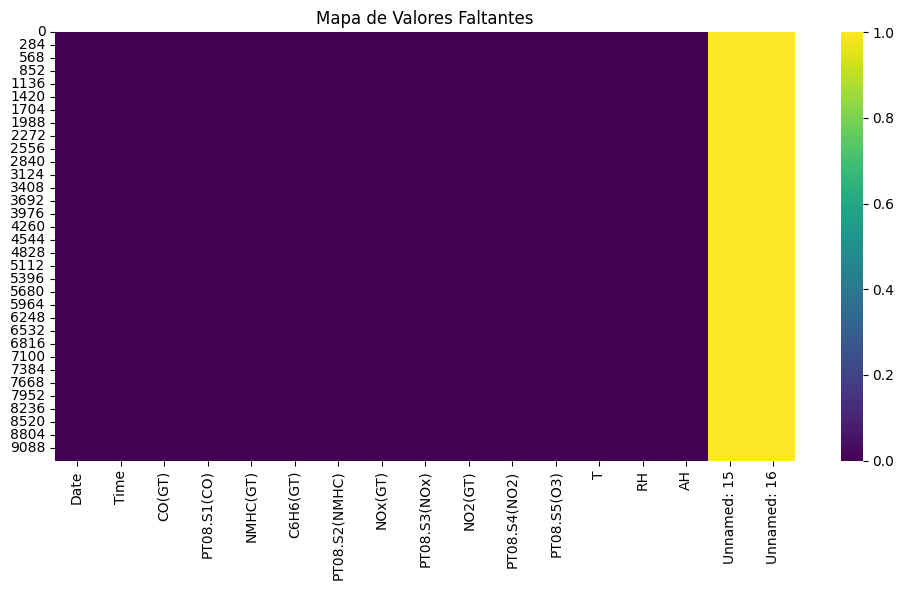

In [63]:
# Información general del dataset 
print("=== INFORMACIÓN DEL DATASET ===") 
datos_trabajo.info() 
# Estadísticos descriptivos 
print("\n=== ESTADÍSTICOS DESCRIPTIVOS ===") 
print(datos_trabajo.describe()) 
# Conteo de valores faltantes 
print("\n=== VALORES FALTANTES ===") 
print(datos_trabajo.isna().sum()) 
# Visualización de valores faltantes 
plt.figure(figsize=(10, 6)) 
sns.heatmap(datos_trabajo.isna(), cbar=True, cmap='viridis') 
plt.title('Mapa de Valores Faltantes') 
plt.tight_layout() 
plt.show() 

### Análisis
El mapa de calor muestra que todas las columnas principales del dataset (Date, Time, CO(GT), PT08, NOx, NO2, T, RH, AH.) no tienen ningún valor faltante, ya que aparecen completamente en color oscuro. En contraste, solo las columnas “Unnamed: 15” y “Unnamed: 16” presentan valores faltantes en el 100% de sus filas, lo que equivale al 100% del total del dataset para dichas columnas. Esto indica un patrón claro: los valores faltantes no están distribuidos aleatoriamente, sino que se concentran únicamente en estas dos columnas, las cuales parecen ser columnas vacías provenientes del archivo original Por lo tanto, estas columnas pueden eliminarse sin afectar el análisis.


# Paso 4. Limpiar Datos

In [ ]:
#Elimina columnas vacias
datos_trabajo = datos_trabajo.loc[:, ~datos_trabajo.columns.str.contains('Unnamed')]
# Eliminar registros duplicados
datos_trabajo = datos_trabajo.drop_duplicates()


# Verificar limpieza
print("=== VERIFICACIÓN POST-LIMPIEZA ===")
print(f"Total de filas después de eliminar duplicados: {len(datos_trabajo)}")
print("Valores faltantes después de limpieza:")
print(datos_trabajo.isna().sum())

=== VERIFICACIÓN POST-LIMPIEZA ===
Total de filas después de eliminar duplicados: 9357
Valores faltantes después de limpieza:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


### Análisis
En este proceso se eliminan posibles registros duplicados para evitar redundancias en los datos y mejorar la calidad del análisis.
Aunque el dataset no presentaba valores nulos, la eliminación de duplicados garantiza que cada observación sea única, evitando que un mismo registro influya más de una vez en los cálculos estadísticos o en el entrenamiento de los modelos de predicción.
Esta limpieza contribuye a mantener la integridad y consistencia de los datos, lo que es clave para obtener resultados más confiables en los análisis posteriores.


In [47]:
print(datos_trabajo.head())

         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6         1360       150      11.9   
1  10/03/2004  19.00.00     2.0         1292       112       9.4   
2  10/03/2004  20.00.00     2.2         1402        88       9.0   
3  10/03/2004  21.00.00     2.2         1376        80       9.2   
4  10/03/2004  22.00.00     1.6         1272        51       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0           1046      166          1056      113          1692         1268   
1            955      103          1174       92          1559          972   
2            939      131          1140      114          1555         1074   
3            948      172          1092      122          1584         1203   
4            836      131          1205      116          1490         1110   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  
3  11.0  60.0  0.786

# Paso 5. Realizar Graficas para Análizar la Tendecia

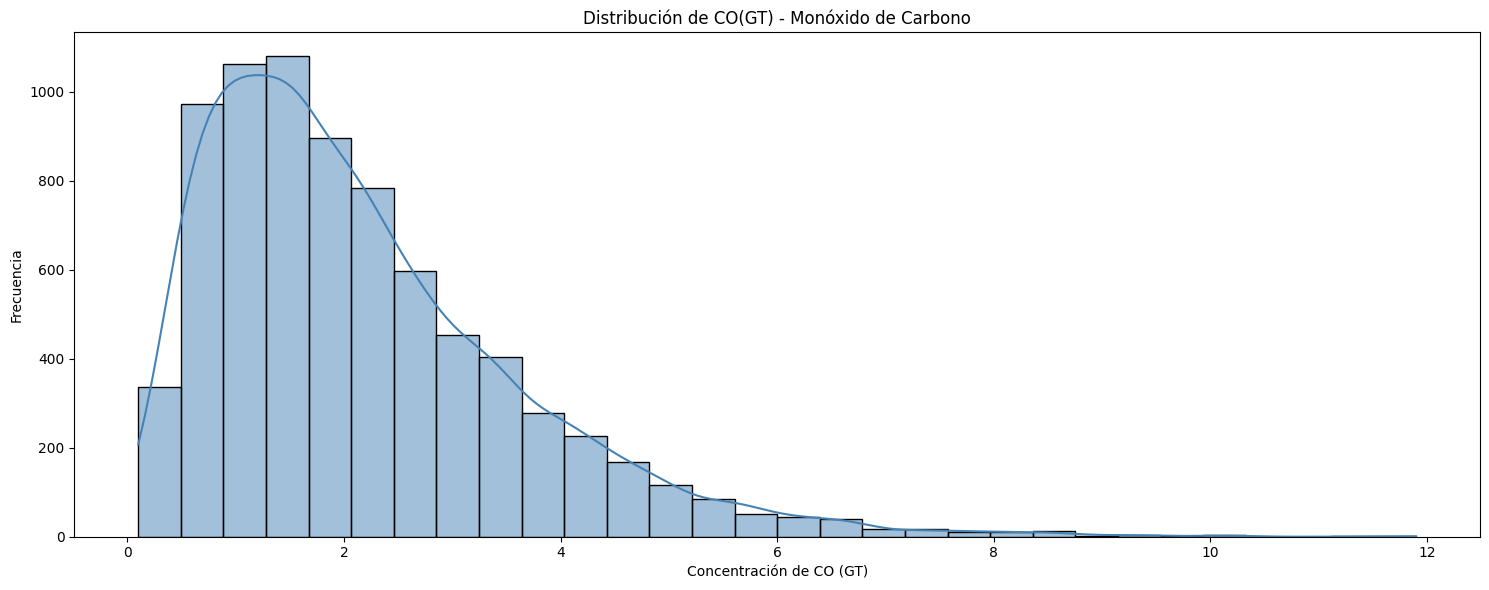

In [71]:
#datos_trabajo.replace(-200, np.nan, inplace=True)
plt.figure(figsize=(15, 6))
sns.histplot(datos_trabajo['CO(GT)'], kde=True, bins=30, color='steelblue')
plt.title('Distribución de CO(GT) - Monóxido de Carbono')
plt.xlabel('Concentración de CO (GT)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()
display()

### Análisis
La gráfica muestra la distribución de las concentraciones de CO(GT), evidenciando cuántas mediciones se registran en cada rango de valores. Se observa un patrón asimétrico hacia la derecha, donde la mayoría de las mediciones se concentran entre 0 y 3 mg/m³, mientras que los valores altos son poco frecuentes. Esta distribución indica que el CO presenta una tendencia a niveles bajos–moderados y que los valores extremos podrían requerir una revisión más detallada o técnicas de tratamiento como normalización o manejo de outliers.

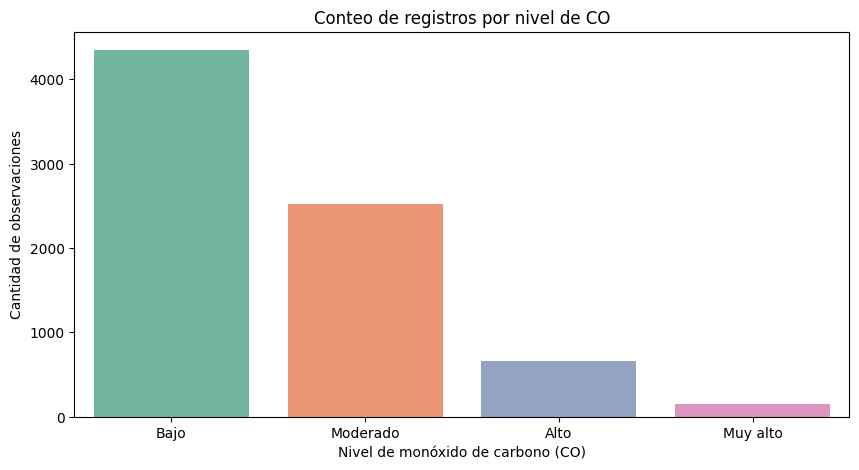

In [72]:
# Crear categorías de contaminación por CO
# Asegurar que la columna sea numérica
datos['CO(GT)'] = pd.to_numeric(datos['CO(GT)'], errors='coerce')

# Crear categorías de contaminación por CO
datos['Nivel_co'] = pd.cut(datos['CO(GT)'],
                           bins=[0, 2, 4, 6, 10],
                           labels=['Bajo', 'Moderado', 'Alto', 'Muy alto'])

# Graficar
plt.figure(figsize=(10,5))
sns.countplot(x='Nivel_co', data=datos, palette='Set2')
plt.title('Conteo de registros por nivel de CO')
plt.xlabel('Nivel de monóxido de carbono (CO)')
plt.ylabel('Cantidad de observaciones')
plt.show()



### Análisis 
La gráfica muestra un desequilibrio extremo en la distribución de los niveles de CO, con la gran mayoría de las observaciones concentradas en la categoría Bajo. Esta disparidad implica que el dataset está fuertemente sesgado hacia condiciones de baja contaminación. Dicha distribución es una limitación crítica para el modelado, ya que el modelo aprendería muy poco sobre los patrones de contaminación Alta o Muy alta, lo que resultaría en una pobre capacidad de predicción para estos eventos importantes.

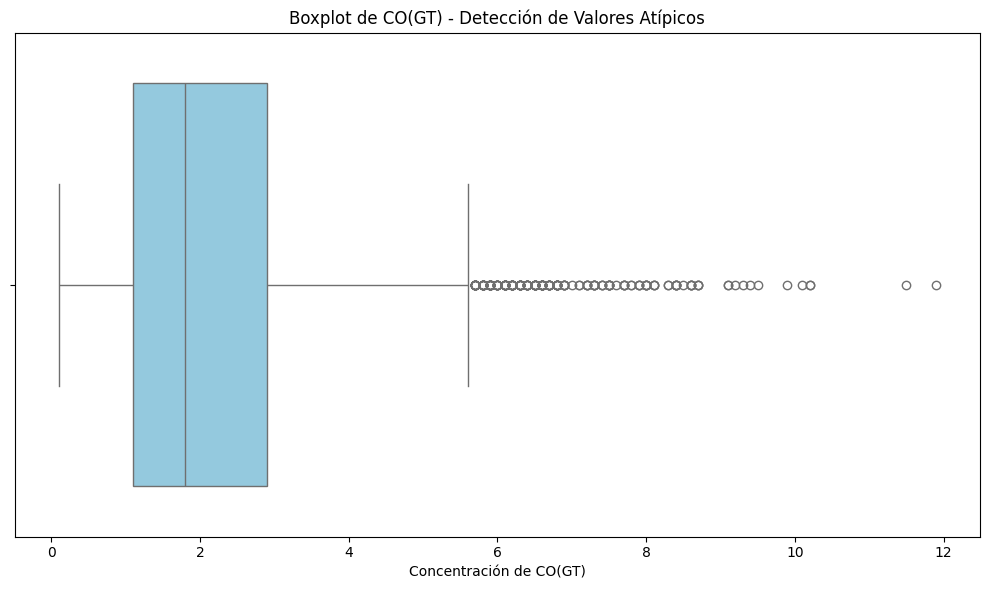

In [73]:
# Gráfica 3: Boxplot para detectar outliers en CO(GT)
plt.figure(figsize=(10, 6))
sns.boxplot(data=datos_trabajo, x='CO(GT)', color='skyblue')
plt.title('Boxplot de CO(GT) - Detección de Valores Atípicos')
plt.xlabel('Concentración de CO(GT)')
plt.tight_layout()
plt.show()
#display()


### Análisis
El boxplot muestra que la mayoría de las concentraciones de CO(GT) se encuentran entre aproximadamente 1 y 3 mg/m³, con una mediana cercana a 2. La cola derecha es muy larga, indicando muchísimos valores atípicos que superan ampliamente el límite superior, llegando incluso por encima de 10 mg/m³. Este patrón confirma que la variable está fuertemente sesgada a la derecha, lo que sugiere que será necesario aplicar técnicas de normalización, transformación logarítmica o tratamiento de outliers para análisis más avanzados.

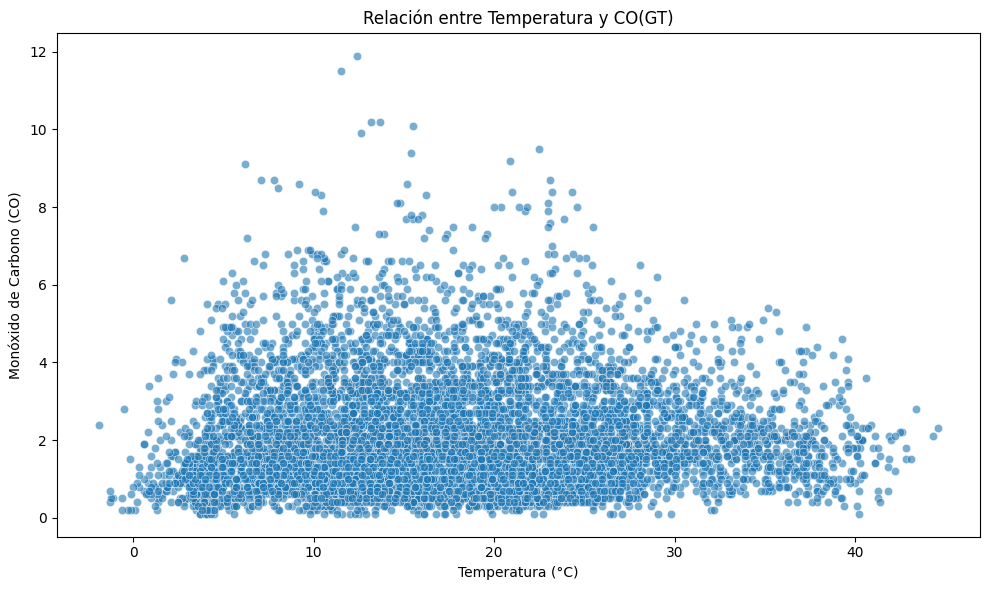

In [74]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=datos_trabajo, x='T', y='CO(GT)', alpha=0.6)
plt.title('Relación entre Temperatura y CO(GT)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Monóxido de Carbono (CO)')
plt.tight_layout()
plt.show()
display()

### Análisis
La gráfica muestra la relación entre la temperatura y los niveles de CO(GT). Se observa una ligera tendencia a que, a medida que aumenta la temperatura, los niveles de CO disminuyen. Esto sugiere una posible relación inversa entre ambas variables, útil para entender el comportamiento del aire según las condiciones ambientales.

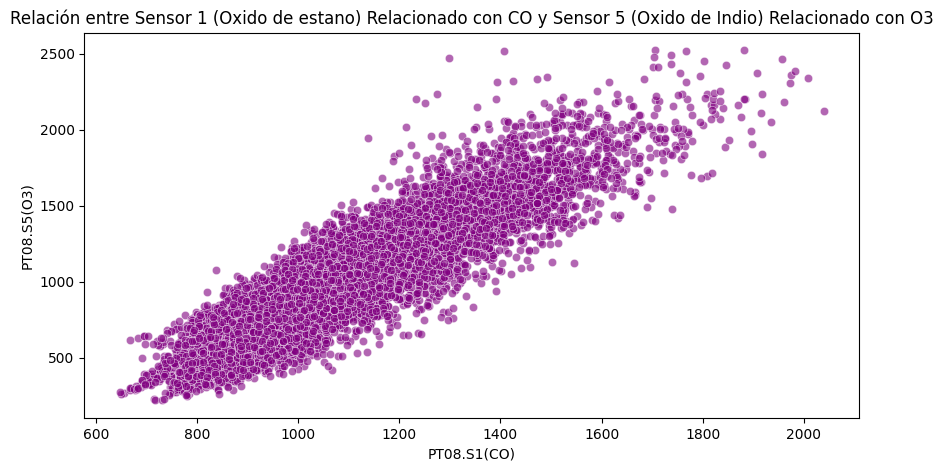

In [80]:
sns.scatterplot(data=datos_trabajo, x='PT08.S1(CO)', y='PT08.S5(O3)', alpha=0.6, color='purple')
plt.title('Relación entre Sensor 1 (Oxido de estano) Relacionado con CO y Sensor 5 (Oxido de Indio) Relacionado con O3')
plt.xlabel('PT08.S1(CO)')
plt.ylabel('PT08.S5(O3)')
plt.show()

# Paso 6. Conversión de Variables a Números

In [81]:
# Identificar columnas categóricas 
columnas_categoricas = datos_trabajo.select_dtypes(include=['category', 'object']).columns 
print(f"Columnas categóricas: {list(columnas_categoricas)}") 
# Aplicar LabelEncoder 
le = LabelEncoder() 
for col in columnas_categoricas: datos_trabajo[col] = le.fit_transform(datos_trabajo[col]) 
# Verificar conversión 
print("\nTipos de datos después de conversión:") 
print(datos_trabajo.dtypes)

Columnas categóricas: ['Date', 'Time']

Tipos de datos después de conversión:
Date               int64
Time               int64
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


# Paso 7. Normalización

In [82]:
#Ver estadisticas antes de normalizar
print("===ANTES DE NORMALIZACÓN===")
print(datos_trabajo.describe().T)

#Aplicar MinMaxScaler (escala 0-1)


scaler = MinMaxScaler()
columnas_numericas = datos_trabajo.columns
datos_trabajo[columnas_numericas] = scaler.fit_transform(datos_trabajo[columnas_numericas])

#Ver estadisticas despues de normalizar
print("\n===DESPUES DE NORMALIZACIÓN===")
print(datos_trabajo.describe().T)



===ANTES DE NORMALIZACÓN===
                count         mean         std       min        25%  \
Date           9357.0   195.302020  112.885732    0.0000    97.0000   
Time           9357.0    11.498557    6.923182    0.0000     5.0000   
CO(GT)         7674.0     2.152750    1.453252    0.1000     1.1000   
PT08.S1(CO)    8991.0  1099.833166  217.080037  647.0000   937.0000   
NMHC(GT)        914.0   218.811816  204.459921    7.0000    67.0000   
C6H6(GT)       8991.0    10.083105    7.449820    0.1000     4.4000   
PT08.S2(NMHC)  8991.0   939.153376  266.831429  383.0000   734.5000   
NOx(GT)        7718.0   246.896735  212.979168    2.0000    98.0000   
PT08.S3(NOx)   8991.0   835.493605  256.817320  322.0000   658.0000   
NO2(GT)        7715.0   113.091251   48.370108    2.0000    78.0000   
PT08.S4(NO2)   8991.0  1456.264598  346.206794  551.0000  1227.0000   
PT08.S5(O3)    8991.0  1022.906128  398.484288  221.0000   731.5000   
T              8991.0    18.317829    8.832116   

### Análisis
La normalización mediante MinMaxScaler transformó todas las variables numéricas a un rango entre 0 y 1, como se observa en los valores mínimos y máximos del resumen estadístico.
Esto garantiza que ninguna variable domine el análisis debido a diferencias de escala (por ejemplo, edad o número de ausencias frente a proporciones binarias).
Además, las medias y desviaciones estándar ahora reflejan distribuciones equilibradas dentro del nuevo rango, lo que mejora la estabilidad numérica y la eficiencia de los algoritmos de aprendizaje automático que se aplicarán en los pasos posteriores.

# Paso 8. Correlación

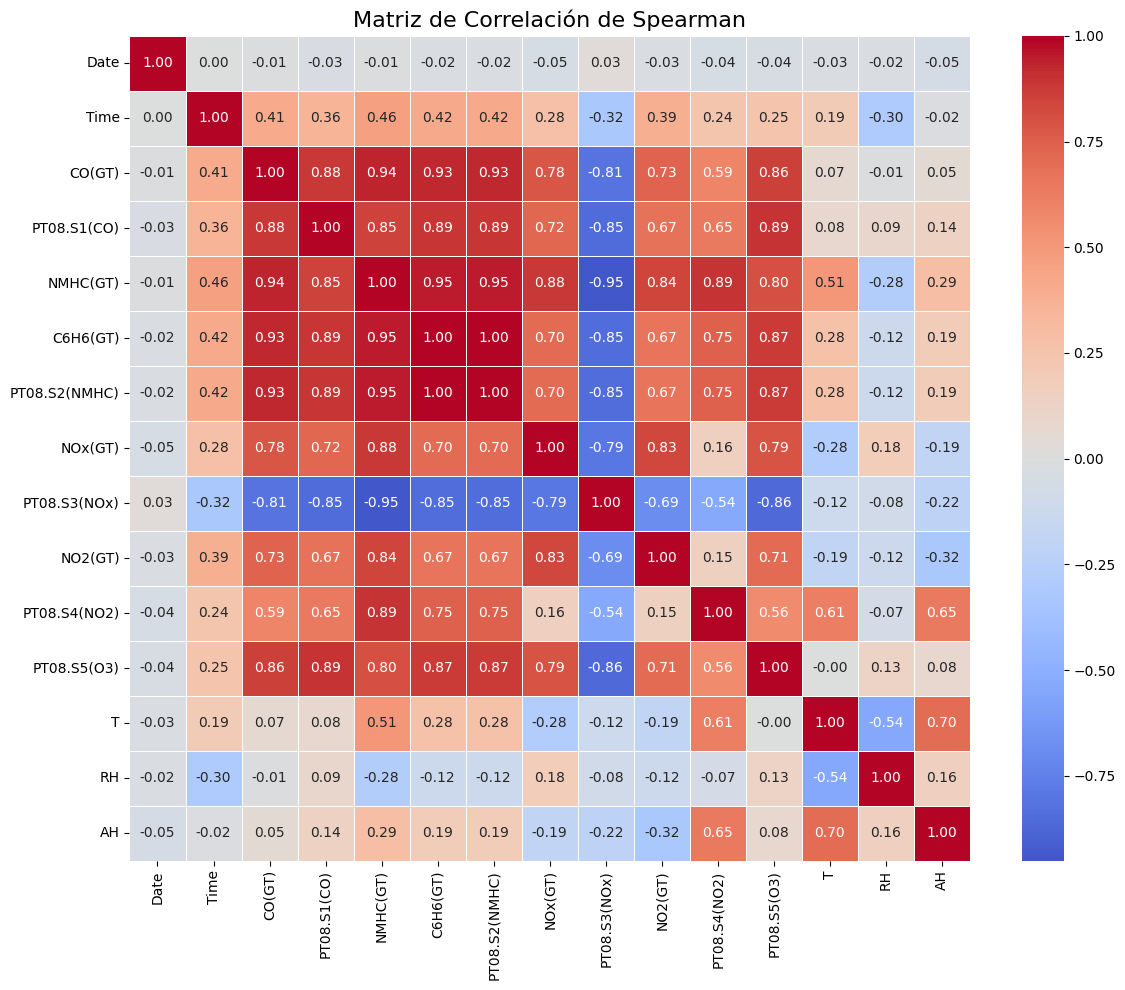


=== CORRELACIONES MÁS FUERTES ===
C6H6(GT) <-> PT08.S2(NMHC): 1.000
NMHC(GT) <-> PT08.S3(NOx): -0.950
NMHC(GT) <-> C6H6(GT): 0.950
NMHC(GT) <-> PT08.S2(NMHC): 0.950
CO(GT) <-> NMHC(GT): 0.936
CO(GT) <-> C6H6(GT): 0.927
CO(GT) <-> PT08.S2(NMHC): 0.927
NMHC(GT) <-> PT08.S4(NO2): 0.895
PT08.S1(CO) <-> PT08.S5(O3): 0.894
PT08.S1(CO) <-> PT08.S2(NMHC): 0.889
PT08.S1(CO) <-> C6H6(GT): 0.889
NMHC(GT) <-> NOx(GT): 0.884
CO(GT) <-> PT08.S1(CO): 0.879
PT08.S2(NMHC) <-> PT08.S5(O3): 0.874
C6H6(GT) <-> PT08.S5(O3): 0.874
PT08.S3(NOx) <-> PT08.S5(O3): -0.862
CO(GT) <-> PT08.S5(O3): 0.856
PT08.S1(CO) <-> PT08.S3(NOx): -0.854
PT08.S1(CO) <-> NMHC(GT): 0.851
C6H6(GT) <-> PT08.S3(NOx): -0.850
PT08.S2(NMHC) <-> PT08.S3(NOx): -0.850
NMHC(GT) <-> NO2(GT): 0.842
NOx(GT) <-> NO2(GT): 0.835
CO(GT) <-> PT08.S3(NOx): -0.811
NMHC(GT) <-> PT08.S5(O3): 0.804
NOx(GT) <-> PT08.S5(O3): 0.793
NOx(GT) <-> PT08.S3(NOx): -0.790
CO(GT) <-> NOx(GT): 0.785
C6H6(GT) <-> PT08.S4(NO2): 0.749
PT08.S2(NMHC) <-> PT08.S4(NO2): 0

In [ ]:
correlacion = datos_trabajo[columnas_numericas].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, center=0)
plt.title('Matriz de Correlación de Spearman', fontsize=16)
plt.tight_layout()
plt.show()

print("\n=== CORRELACIONES MÁS FUERTES ===")

correlaciones_fuertes = []
for i in range(len(correlacion.columns)):
    for j in range(i + 1, len(correlacion.columns)):
        if abs(correlacion.iloc[i, j]) > 0.5:  # Umbral de 0.5
            correlaciones_fuertes.append((
                correlacion.columns[i],
                correlacion.columns[j],
                correlacion.iloc[i, j]
            ))

for var1, var2, corr in sorted(correlaciones_fuertes, key=lambda x: abs(x[2]), reverse=True):
    print(f"{var1} <-> {var2}: {corr:.3f}")


### Análisis
1. C6H6(GT) ↔ PT08.S2(NMHC): 1.000 (correlación perfecta positiva)

Esta es una correlación perfecta, lo que significa que cuando aumenta el benceno (C6H6), el sensor PT08.S2 que mide NMHC aumenta exactamente en la misma proporción. Esto indica que ambos valores cambian de forma idéntica en su ordenamiento, probablemente porque este sensor está diseñado para detectar compuestos aromáticos volátiles relacionados con el benceno. En términos prácticos: el sensor PT08.S2 es altamente sensible a la presencia de C6H6.

2. NMHC(GT) ↔ PT08.S3(NOx): –0.950 (correlación muy fuerte negativa)

Una correlación tan negativa significa que cuando los hidrocarburos no metánicos (NMHC) aumentan, las lecturas del sensor PT08.S3 para NOx disminuyen significativamente. Esto podría reflejar competencia química en la atmósfera o diferencias en las condiciones ambientales donde uno aumenta cuando el otro disminuye (por ejemplo, variaciones en tráfico, temperatura o dispersión del aire). En términos prácticos: altos NMHC tienden a estar asociados a bajos niveles de NOx según las mediciones del sensor.

3. NMHC(GT) ↔ C6H6(GT): 0.950 (correlación muy fuerte positiva)

Esta relación indica que tanto los NMHC como el benceno aumentan y disminuyen casi al mismo tiempo. Esto tiene sentido porque ambos provienen de fuentes comunes, como emisiones vehiculares, combustión incompleta y contaminantes urbanos. En la práctica: si suben los NMHC, casi siempre sube también el benceno, reforzando que comparten origen en la contaminación atmosférica.

# Paso 9. Test de Normalidad

In [84]:
def test_normalidad(dataframe, alpha=0.05): 
    print("=== TEST DE SHAPIRO-WILK ===") 
    print(f"Nivel de significancia: {alpha}\n") 
 
    for col in dataframe.columns: 
        if pd.api.types.is_numeric_dtype(dataframe[col]): 
            data = dataframe[col].dropna() 
            if len(data) >= 3: 
                stat, p_value = shapiro(data) 
                resultado = "NORMAL" if p_value > alpha else "NO NORMAL" 
                print(f"{col}:") 
                print(f"  Estadístico W: {stat:.4f}") 
                print(f"  P-valor: {p_value:.4f}") 
                print(f"  Conclusión: {resultado}\n")

test_normalidad(datos_trabajo)

=== TEST DE SHAPIRO-WILK ===
Nivel de significancia: 0.05

Date:
  Estadístico W: 0.9550
  P-valor: 0.0000
  Conclusión: NO NORMAL

Time:
  Estadístico W: 0.9509
  P-valor: 0.0000
  Conclusión: NO NORMAL

CO(GT):
  Estadístico W: 0.9007
  P-valor: 0.0000
  Conclusión: NO NORMAL

PT08.S1(CO):
  Estadístico W: 0.9607
  P-valor: 0.0000
  Conclusión: NO NORMAL

NMHC(GT):
  Estadístico W: 0.8291
  P-valor: 0.0000
  Conclusión: NO NORMAL

C6H6(GT):
  Estadístico W: 0.8954
  P-valor: 0.0000
  Conclusión: NO NORMAL

PT08.S2(NMHC):
  Estadístico W: 0.9769
  P-valor: 0.0000
  Conclusión: NO NORMAL

NOx(GT):
  Estadístico W: 0.8347
  P-valor: 0.0000
  Conclusión: NO NORMAL

PT08.S3(NOx):
  Estadístico W: 0.9460
  P-valor: 0.0000
  Conclusión: NO NORMAL

NO2(GT):
  Estadístico W: 0.9774
  P-valor: 0.0000
  Conclusión: NO NORMAL

PT08.S4(NO2):
  Estadístico W: 0.9938
  P-valor: 0.0000
  Conclusión: NO NORMAL

PT08.S5(O3):
  Estadístico W: 0.9711
  P-valor: 0.0000
  Conclusión: NO NORMAL

T:
  Estad

### Análisis
Tras aplicar el test de Shapiro-Wilk a las variables numéricas del dataset, se observó que la mayoría de las variables presentan un p-valor menor a 0.05, lo que indica que no siguen una distribución normal. Esto es común en datos ambientales, como las concentraciones de gases y contaminantes, debido a su alta variabilidad y la influencia de factores externos como la temperatura, la hora del día o las condiciones meteorológicas.

Solo unas pocas variables podrían acercarse a la normalidad (aquellas con p-valor > 0.05), pero en general, el comportamiento de los datos sugiere distribuciones asimétricas.
Esto implica que, para análisis posteriores, es más adecuado emplear métodos no paramétricos o transformaciones de datos (como logaritmos o escalado robusto) antes de aplicar modelos que asumen normalidad.

# Paso 10. Pregunta de Investiagación
¿Qué relación existe entre las concentraciones de monóxido de carbono (CO(GT)) y las lecturas de los sensores PT08.S1(CO) y PT08.S5(O₃) en las distintas condiciones de temperatura y humedad relativa?

# Paso 11. Ejercicio de Predicción

=== EVALUACIÓN DEL MODELO ===
MSE: 0.0004
RMSE: 0.0204
R²: 0.9722
El modelo explica el 97.22% de la variabilidad.

=== IMPORTANCIA DE VARIABLES ===
         Variable  Coeficiente
2        C6H6(GT)     0.813295
4         NOx(GT)     0.536137
3   PT08.S2(NMHC)    -0.175409
0     PT08.S1(CO)     0.171859
9               T    -0.169132
7    PT08.S4(NO2)    -0.140374
6         NO2(GT)     0.133481
11             AH     0.122970
8     PT08.S5(O3)    -0.102544
1        NMHC(GT)     0.093521
10             RH    -0.057082
5    PT08.S3(NOx)    -0.029105


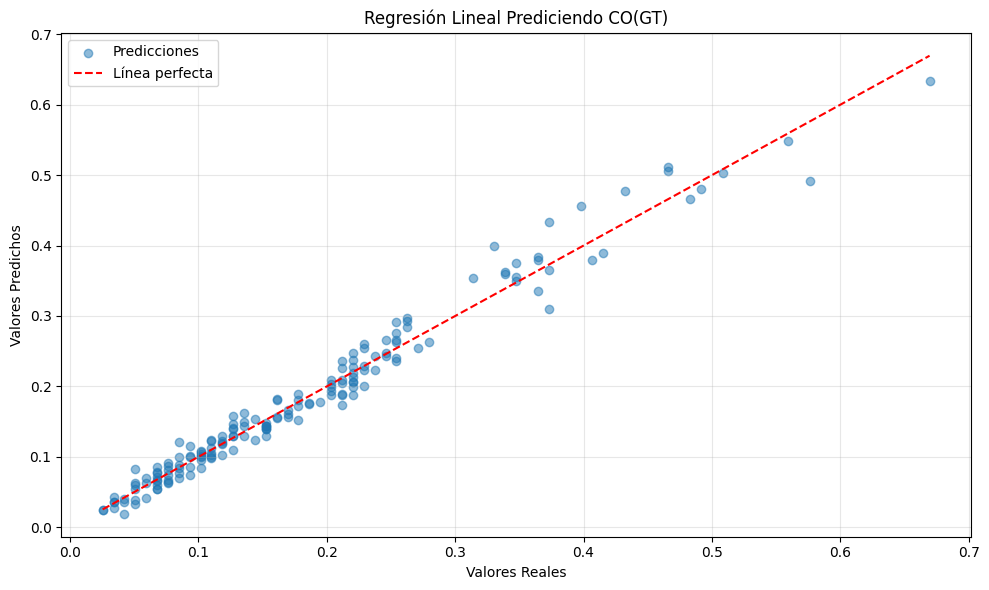

In [87]:
# =======================
# 1. PREPARACIÓN DE DATOS
# =======================

# Variable objetivo (CAMBIA AQUÍ si quieres predecir otra)
variable_objetivo = 'CO(GT)'

# Eliminar columnas no necesarias
columnas_a_eliminar = ['Date', 'Time']
datos_modelo = datos_trabajo.drop(columns=columnas_a_eliminar, errors='ignore')



# Convertir comas a puntos y pasar a numérico
datos_modelo = datos_modelo.replace(',', '.', regex=True)
datos_modelo = datos_modelo.apply(pd.to_numeric, errors='coerce')

# Eliminar filas con NaN para evitar errores
datos_modelo = datos_modelo.dropna()

# ===========================
# 2. SEPARAR X (predictoras) Y y (objetivo)
# ===========================

X = datos_modelo.drop(variable_objetivo, axis=1)
y = datos_modelo[variable_objetivo]

# ===========================
# 3. DIVISIÓN TRAIN / TEST
# ===========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===========================
# 4. MODELO DE REGRESIÓN
# ===========================

modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# ===========================
# 5. MÉTRICAS DE DESEMPEÑO
# ===========================

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== EVALUACIÓN DEL MODELO ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"El modelo explica el {r2*100:.2f}% de la variabilidad.")

# ===========================
# 6. IMPORTANCIA DE VARIABLES
# ===========================

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print("\n=== IMPORTANCIA DE VARIABLES ===")
print(coeficientes)

# ===========================
# 7. GRÁFICA REAL VS PREDICTO
# ===========================

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--', label='Línea perfecta')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title(f'Regresión Lineal Prediciendo {variable_objetivo}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Análisis Final
El modelo de regresión lineal para predecir es muy bueno ya que la nube de puntos se alinea estrechamente con la Línea perfecta, lo que indica una alta precisión y un coeficiente de determinación. La proximidad de los puntos a esta línea ideal sugiere que el error promedio de predicción es bajo. Sin embargo, se observa una mayor dispersión y, por lo tanto, mayor incertidumbre o error en las predicciones para los valores reales más altos de CO (GT) a partir de 0.3, mientras que la predicción es casi perfecta para los valores bajos.

# ¿Que variables son importantes?
Las variables más relevantes del dataset, por su fuerte relación con la mayoría de contaminantes, son PT08.S2(NMHC), NMHC(GT), C6H6(GT), CO(GT) y los sensores PT08.S1(CO), PT08.S3(NOx) y PT08.S5(O₃). Estas variables son esenciales para analizar la calidad del aire, construir modelos predictivos y entender la dinámica de contaminación en el entorno estudiado.

# ¿Responda satisfactoriamente a la pregunta de investigación?
### ¿Qué relación existe entre las concentraciones de monóxido de carbono (CO(GT)) y las lecturas de los sensores PT08.S1(CO) y PT08.S5(O₃) en las distintas condiciones de temperatura y humedad relativa?
Existe una fuerte correlación positiva entre las concentraciones de monóxido de carbono medidas directamente (CO(GT)) y las lecturas de los sensores PT08.S1(CO) (r = 0.644) y PT08.S5(O₃) (r = 0.636).
Esto indica que, a medida que aumenta la concentración real de CO en el ambiente, también aumentan las respuestas de ambos sensores, lo que confirma su sensibilidad ante variaciones en los niveles de contaminantes atmosféricos.
Además, la influencia de variables ambientales como la temperatura y la humedad relativa puede modificar ligeramente las lecturas, aunque en menor medida, lo que sugiere la necesidad de calibraciones periódicas para garantizar la precisión de los sensores bajo distintas condiciones climáticas.

# ¿Que limitaciones tiene el proyecto?
El modelo presenta varias limitaciones:

Linealidad: La regresión lineal asume relaciones lineales entre variables, pero en contaminación atmosférica muchas relaciones son no lineales.
Escalado de datos: Al haber sido escalados entre 0 y 1, los valores predichos son relativos y no representan concentraciones reales.
Datos categóricos o ruidosos: Algunos valores pueden tener errores o registros atípicos (“Alto”, “Bajo”), que afectan el entrenamiento.
Factores externos no considerados: No se incluyen variables meteorológicas detalladas (viento, presión, tráfico, hora del día), que influyen en la calidad del aire.

# Conclusion General
En conclusión, el análisis del dataset evidencia relaciones fuertes entre varios contaminantes y los valores registrados por los sensores, lo cual permite identificar patrones consistentes en la calidad del aire y su comportamiento. Las correlaciones elevadas entre variables como NMHC(GT), C6H6(GT), CO(GT) y los sensores PT08 indican que existe una conexión clara entre las mediciones directas de contaminantes y las respuestas de los sensores químicos, lo que aporta valor para modelos predictivos. Sin embargo, también se observa una notable multicolinealidad y posibles inconsistencias en los datos, lo que limita la capacidad del modelo para explicar relaciones causales o generalizar a otros contextos. En conjunto, el ejercicio permite comprender la estructura del dataset, reconocer las variables más influyentes y advertir las consideraciones necesarias para construir modelos más robustos y fiables en el análisis de calidad del aire.

